# For viewing Images

**WARNING Execute "match_lables_with_gt.ipynb" beforehand!**

## Functions for constructing the images

In [6]:
from pathlib import Path

import matplotlib.pyplot as plt
import matplotlib.patches as patches
from PIL import Image
import pandas as pd
from utils import PROJECT_ROOT, build_group_boxes, resolve_frame_paths

In [2]:
bb = pd.read_csv(PROJECT_ROOT/f"data/bounding_boxes_with_labels/all.csv")
bb["frame_name"] = bb["flight"].astype(str)+"_"+bb["frame"].astype(str)
bb.head(5)

,flight,frame,class_id,species,txt_x1,txt_y1,txt_x2,txt_y2,txt_h,txt_w,frame_name
0,1,11726,1,Cervus elaphus (Red deer),709,578,749,632,53,40,1_11726
1,17,14339,5,Cervus elaphus (Red deer),456,102,510,146,43,54,17_14339
2,17,14342,5,Cervus elaphus (Red deer),454,115,507,161,46,52,17_14342
3,17,14343,5,Cervus elaphus (Red deer),449,141,506,191,50,56,17_14343
4,17,14349,5,Cervus elaphus (Red deer),447,178,504,228,49,57,17_14349


In [3]:
for id, (class_id, x_c, y_c, w, h) in bb[bb["frame_name"] == "55_4542"][["species", "txt_x1", "txt_y1", "txt_w", "txt_h"]].iterrows():
    print(class_id)

Cervus elaphus (Red deer)
Cervus elaphus (Red deer)


In [7]:
def show_frame_with_boxes(frame_id: str, boxes: pd.DataFrame):
    """Load a frame by id, auto-detect split, and visualize YOLO boxes."""
    boxes = boxes[boxes["frame_name"] == frame_id]
    split, image_path, label_path = resolve_frame_paths(frame_id)

    image = Image.open(image_path).convert("RGB")
    img_w, img_h = image.size

    fig, ax = plt.subplots(figsize=(9, 9))
    ax.imshow(image)

    for _, (class_id, x_min, y_min, box_w, box_h) in boxes[["species", "txt_x1", "txt_y1", "txt_w", "txt_h"]].iterrows():#type:ignore
        rect = patches.Rectangle((x_min, y_min), box_w, box_h, linewidth=2, edgecolor="lime", facecolor="none")#type:ignore
        ax.add_patch(rect)
        ax.text(x_min, max(y_min - 11, 2), f"class {class_id}", color="yellow", fontsize=10, backgroundcolor="black")
    
    groups = build_group_boxes(boxes)
    for _, (_, x_min, y_min, box_w, box_h, _, species) in groups.iterrows():
        rect = patches.Rectangle((x_min, y_min), box_w, box_h, linewidth=2, edgecolor="cyan", facecolor="none")#type:ignore
        ax.add_patch(rect)
        ax.text(x_min, max(y_min-20, 2), f"Group {species[0] if len(species) == 0 else ' / '.join(species)}", color="cyan", fontsize=10, backgroundcolor="black")
    

    ax.set_title(f"Frame {frame_id} from {split} with YOLO boxes")
    ax.axis("off")
    
    print(f"Split: {split}")
    print(f"Image size: {img_w} x {img_h}")
    print(f"Label file: {label_path.name}")
    print(f"Number of boxes: {len(boxes)}")
    print(f"Number of groups: {len(groups)}")
    
    plt.show()

## Usage

Split: train
Image size: 1024 x 1024
Label file: 104_1545.txt
Number of boxes: 3
Number of groups: 2


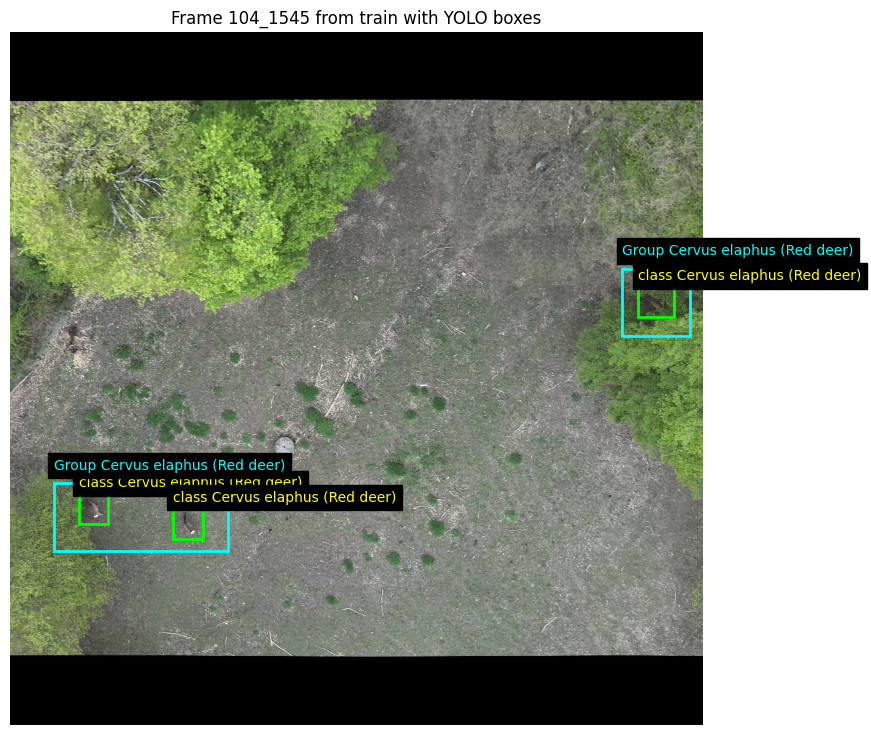

In [8]:
# Demo: show the same frame currently used in this notebook.
frame_id = "104_1545"
frame_info = show_frame_with_boxes(frame_id, bb[bb["frame_name"] == frame_id])